# Digit Recognizer

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# - Get the Data

In [2]:
digit_recog_dataset = pd.read_csv('digit-recognizer/train.csv')
print(digit_recog_dataset.shape)

(42000, 785)


In [4]:
digit_images, labels = digit_recog_dataset.drop('label', axis=1), digit_recog_dataset['label'].copy()
print(type(digit_images), digit_images.shape, digit_images.ndim, digit_images.dtypes.iloc[0])
print(type(labels), labels.shape, labels.ndim, labels.dtypes)

<class 'pandas.core.frame.DataFrame'> (42000, 784) 2 int64
<class 'pandas.core.series.Series'> (42000,) 1 int64


In [5]:
digit_images = digit_images.astype('float32') / 255
labels = np.asarray(labels)
print(type(digit_images), digit_images.shape, digit_images.ndim, digit_images.dtypes.iloc[0])
print(type(labels), labels.shape, labels.ndim, labels.dtype)

<class 'pandas.core.frame.DataFrame'> (42000, 784) 2 float32
<class 'numpy.ndarray'> (42000,) 1 int64


In [6]:
# split the data
from sklearn.model_selection import train_test_split

train_images, valid_images, train_labels, valid_labels = train_test_split(digit_images, labels, test_size=0.2, random_state=42, stratify=labels)
print(train_images.shape)
print(valid_images.shape)
print(train_labels.shape)
print(valid_labels.shape)

(33600, 784)
(8400, 784)
(33600,)
(8400,)


In [7]:
np.max(train_images.iloc[:5])

1.0

In [74]:
# Voting Classifier
from sklearn.ensemble import VotingClassifier

# build
voting_ensemble = VotingClassifier([
    ('svm', SVC(C=10, gamma='scale', probability=True)),
    ('rf', grid_rf.best_estimator_),
    ('knn', grid_knn.best_estimator_)
], voting='soft')

# train
voting_ensemble.fit(X_train_norm, y_train)
voting_ensemble_score = voting_ensemble.score(X_valid_norm, y_valid)
print(voting_ensemble_score)

0.9786904761904762


roughly 0.979, highest estimator in ensemble was svm with 0.978

In [76]:
# Stacking Classifier
from sklearn.ensemble import StackingClassifier

# build 
stack = StackingClassifier(
    estimators=[
        ('svm', grid_svm.best_estimator_),
        ('rf', grid_rf.best_estimator_),
        ('knn', grid_knn.best_estimator_)
    ], 
    final_estimator=grid_lr.best_estimator_
)

# train
stack.fit(X_train_norm, y_train)
stack_score = stack.score(X_valid_norm, y_valid)
print(stack_score)

0.9778571428571429


In [77]:
# grid search models
grid_models = [grid_svm, grid_rf, grid_knn, grid_lr]

for model in grid_models:
    current_model = model.best_estimator_
    y_pred = current_model.predict(X_valid_norm)
    print(model)
    print(f'Acc: {accuracy_score(y_valid, y_pred)}\n')

GridSearchCV(cv=5, estimator=SVC(decision_function_shape='ovo'), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']},
             scoring='accuracy')
Acc: 0.979047619047619

GridSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': [5, 10], 'n_estimators': [100, 200]},
             scoring='accuracy')
Acc: 0.9451190476190476

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'n_neighbors': [3, 5, 7]}, scoring='accuracy')
Acc: 0.9663095238095238

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000, random_state=42),
             n_jobs=-1, param_grid={'C': [0.1, 1, 10]}, scoring='accuracy')
Acc: 0.9167857142857143



svm is still the highest estimator, now with 0.979

# Models

In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

## ~ a baseline model

In [15]:
def get_baseline_model():
    # inputs = keras.Input(shape=(784,))
    # x = layers.Dense(256, activation='relu') (inputs)
    # x = layers.Dropout(0.2) (x)
    # x = layers.Dense(512, activation='relu') (x)
    # x = layers.Dropout(0.2) (x)
    # x = layers.Dense(128, activation='relu') (x)
    # x = layers.Dropout(0.2) (x)
    # x = layers.Dense(64, activation='relu') (inputs)
    # outputs = layers.Dense(10, activation='softmax') (x)
    # baseline_model = keras.Model(inputs, outputs)
   
    baseline_model = keras.models.Sequential([
        layers.Dense(300, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(100, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(10, activation='softmax')
    ])
    
    baseline_model.compile(optimizer='rmsprop', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return baseline_model

In [16]:
callbacks_list = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath='checkpoint_models/model_w_dropout.keras',
        monitor='val_loss',
        save_best_only=True,
    )
]

baseline_model = get_baseline_model()

In [17]:
baseline_history = baseline_model.fit(train_images, train_labels, epochs=50, callbacks=callbacks_list, validation_data=(valid_images, valid_labels))

Epoch 1/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9018 - loss: 0.3236 - val_accuracy: 0.9529 - val_loss: 0.1540
Epoch 2/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9562 - loss: 0.1496 - val_accuracy: 0.9636 - val_loss: 0.1255
Epoch 3/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9672 - loss: 0.1169 - val_accuracy: 0.9689 - val_loss: 0.1107
Epoch 4/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9739 - loss: 0.0919 - val_accuracy: 0.9718 - val_loss: 0.1281
Epoch 5/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9755 - loss: 0.0865 - val_accuracy: 0.9714 - val_loss: 0.1212
Epoch 6/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9782 - loss: 0.0746 - val_accuracy: 0.9744 - val_loss: 0.1000
Epoch 7/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9807 - loss: 0.0662 - val_accuracy: 0.9727 - val_loss: 0.1215
Epoch 8/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9831 - loss: 0.0593 - 

In [18]:
val_acc = baseline_history.history['val_accuracy']
val_loss = baseline_history.history['val_loss']
train_acc = baseline_history.history['accuracy']
train_loss = baseline_history.history['loss']

print(np.max(val_acc))
print(np.min(val_loss))
print(f'accuracy overfitting factor: {np.abs(train_acc[-1] - val_acc[-1]) * 100}')
print(f'loss overfitting factor: {np.abs(val_loss[-1] - train_loss[-1]) * 100}')

0.9778571724891663
0.09997840970754623
accuracy overfitting factor: 1.5714287757873535
loss overfitting factor: 16.309664584696293


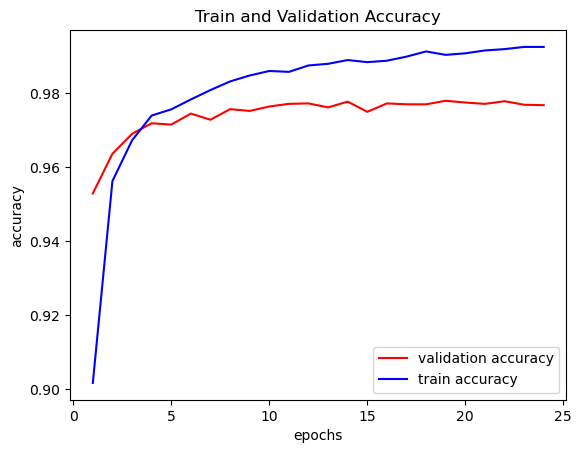

In [20]:
epochs = range(1, len(val_acc) + 1)
plt.plot(epochs, val_acc, 'r', label='validation accuracy')
plt.plot(epochs, train_acc, 'b', label='train accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.title('Train and Validation Accuracy')
plt.legend()

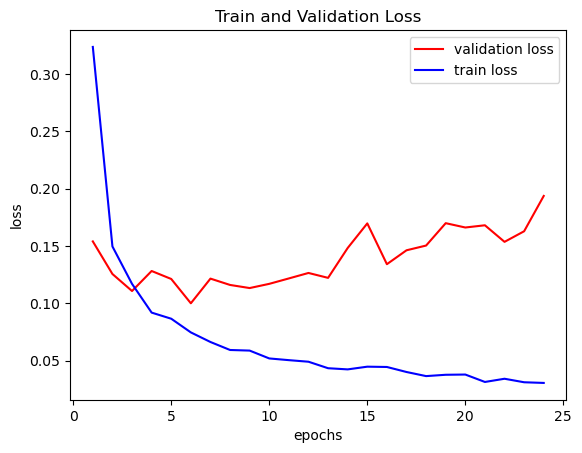

In [21]:
plt.plot(epochs, val_loss, 'r', label='validation loss')
plt.plot(epochs, train_loss, 'b', label='train loss')
plt.title('Train and Validation Loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

## ~ Convnet

In [22]:
def get_convnet():
    inputs = keras.Input(shape=(28, 28, 1))
    x = layers.Conv2D(filters=32, kernel_size=3, activation='relu') (inputs)
    x = layers.MaxPooling2D(pool_size=2) (x)
    x = layers.Conv2D(filters=64, kernel_size=3, activation='relu') (x)
    x = layers.MaxPooling2D(pool_size=2) (x)
    x = layers.Conv2D(filters=128, kernel_size=3, activation='relu') (x)
    x = layers.Flatten() (x)
    outputs = layers.Dense(10, activation='softmax', name='output_layer') (x)
    model = keras.Model(inputs, outputs)
    model.compile(optimizer='rmsprop', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [11]:
# lil data-preproc
print(train_images.shape, valid_images.shape)
train_images = train_images.values.reshape(len(train_images), 28, 28, 1)
valid_images = valid_images.values.reshape(len(valid_images), 28, 28, 1)
print(train_images.shape, valid_images.shape)

(33600, 784) (8400, 784)
(33600, 28, 28, 1) (8400, 28, 28, 1)


In [28]:
# train
callbacks_list = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath='checkpoint_models/model_convnet_19_1.keras',
        monitor='val_loss',
        save_best_only=True,
    )
]

convnet_model = get_convnet()

In [29]:
convnet_history = convnet_model.fit(train_images, train_labels, epochs=50, callbacks=callbacks_list, validation_data=(valid_images, valid_labels))

Epoch 1/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9432 - loss: 0.1804 - val_accuracy: 0.9786 - val_loss: 0.0710
Epoch 2/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9839 - loss: 0.0501 - val_accuracy: 0.9850 - val_loss: 0.0470
Epoch 3/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9888 - loss: 0.0343 - val_accuracy: 0.9863 - val_loss: 0.0505
Epoch 4/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9917 - loss: 0.0262 - val_accuracy: 0.9893 - val_loss: 0.0355
Epoch 5/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9947 - loss: 0.0185 - val_accuracy: 0.9876 - val_loss: 0.0436
Epoch 6/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9958 - loss: 0.0139 - val_accuracy: 0.9890 - val_loss: 0.0431
Epoch 7/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9966 - loss: 0.0121 - val_accuracy: 0.9892 - val_loss: 0.0461
Epoch 8/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9975 - loss: 0.009

In [30]:
val_acc = convnet_history.history['val_accuracy']
val_loss = convnet_history.history['val_loss']
train_acc = convnet_history.history['accuracy']
train_loss = convnet_history.history['loss']
epochs = range(1, len(val_acc) + 1)

In [33]:
print(np.max(val_acc))
print(np.min(val_loss))
print(f'acc offset ratio: {np.abs(train_acc[-1] - val_acc[-1]) * 100}')
print(f'loss offset ratio: {np.abs(val_loss[-1] - train_loss[-1]) * 100}')

0.9892857074737549
0.035504043102264404
acc offset ratio: 0.9999990463256836
loss offset ratio: 4.713950352743268


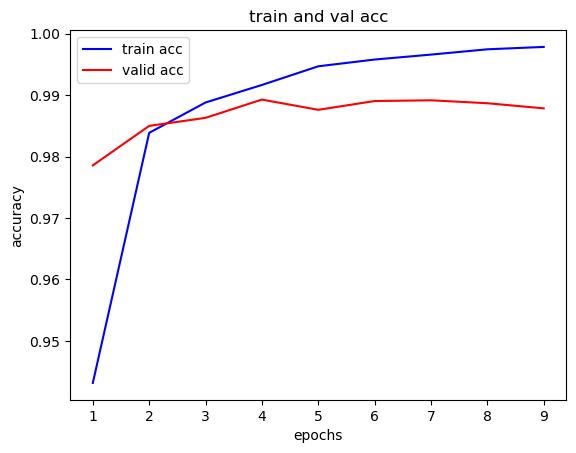

In [34]:
plt.plot(epochs, train_acc, 'b', label='train acc')
plt.plot(epochs, val_acc, 'r', label='valid acc')
plt.title('train and val acc')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

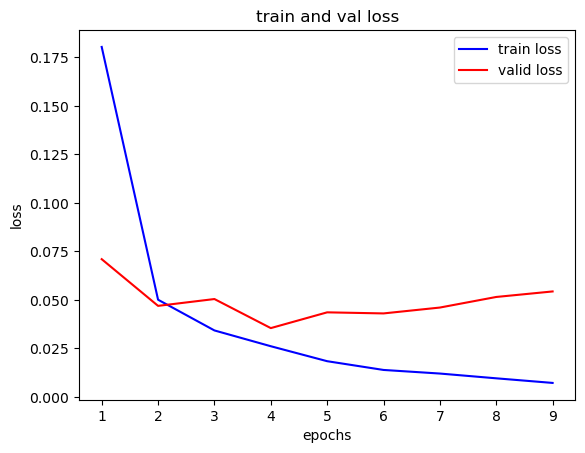

In [35]:
plt.plot(epochs, train_loss, 'b', label='train loss')
plt.plot(epochs, val_loss, 'r', label='valid loss')
plt.title('train and val loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

## data augmentation to counter overfitting

In [37]:
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
])

In [80]:
def get_convnet_w_data_augmentation():
    inputs = keras.Input(shape=(28, 28, 1))
    # x = data_augmentation(inputs)
    x = layers.Conv2D(filters=32, kernel_size=3, activation='relu') (inputs)
    x = layers.MaxPooling2D(pool_size=2) (x)
    x = layers.Conv2D(filters=64, kernel_size=3, activation='relu') (x)
    x = layers.MaxPooling2D(pool_size=2) (x)
    x = layers.Conv2D(filters=128, kernel_size=3, activation='relu') (x)
    x = layers.Flatten() (x)
    x = layers.Dropout(0.2) (x)
    outputs = layers.Dense(10, activation='softmax', name='output_layer') (x)
    model = keras.Model(inputs, outputs)
    model.compile(optimizer='rmsprop', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [81]:
# train
callbacks_list = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath='checkpoint_models/model_convnet_w_aug6_19_1.keras',
        monitor='val_loss',
        save_best_only=True,
    )
]

convnet_aug_model = get_convnet_w_data_augmentation()

In [82]:
history = convnet_aug_model.fit(train_images, train_labels, epochs=50, callbacks=callbacks_list, validation_data=(valid_images, valid_labels))

Epoch 1/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9369 - loss: 0.2001 - val_accuracy: 0.9787 - val_loss: 0.0715
Epoch 2/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9824 - loss: 0.0586 - val_accuracy: 0.9829 - val_loss: 0.0573
Epoch 3/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9873 - loss: 0.0421 - val_accuracy: 0.9880 - val_loss: 0.0381
Epoch 4/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9898 - loss: 0.0333 - val_accuracy: 0.9871 - val_loss: 0.0412
Epoch 5/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9918 - loss: 0.0263 - val_accuracy: 0.9888 - val_loss: 0.0369
Epoch 6/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9938 - loss: 0.0203 - val_accuracy: 0.9889 - val_loss: 0.0419
Epoch 7/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9945 - loss: 0.0180 - val_accuracy: 0.9906 - val_loss: 0.0368
Epoch 8/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9959 - loss: 0.01

In [83]:
val_acc, val_loss = history.history['val_accuracy'], history.history['val_loss']
train_acc, train_loss = history.history['accuracy'], history.history['loss']
print(np.max(val_acc))
print(np.min(val_loss))

0.9916666746139526
0.03681698068976402


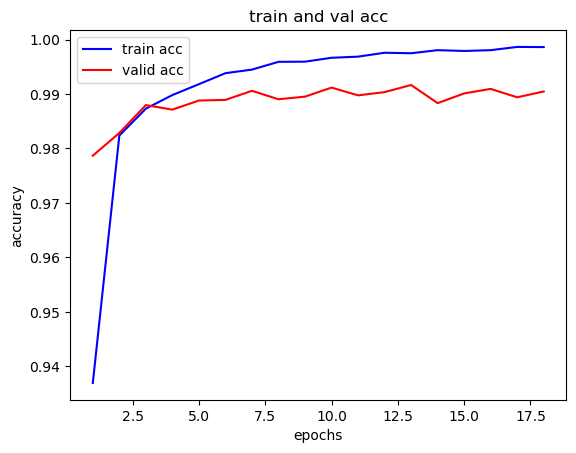

In [84]:
epochs = range(1, len(val_acc) + 1)
plt.plot(epochs, train_acc, 'b', label='train acc')
plt.plot(epochs, val_acc, 'r', label='valid acc')
plt.title('train and val acc')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

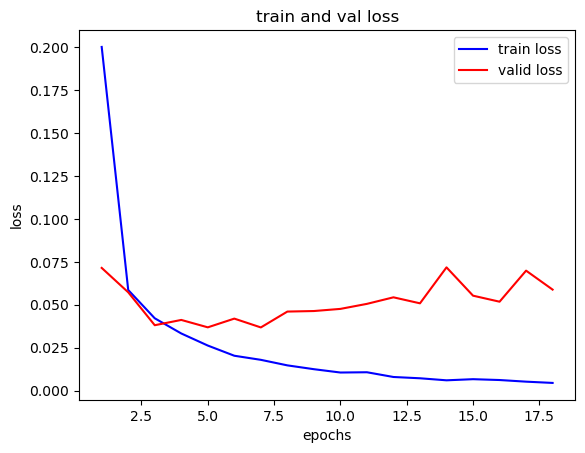

In [85]:
plt.plot(epochs, train_loss, 'b', label='train loss')
plt.plot(epochs, val_loss, 'r', label='valid loss')
plt.title('train and val loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

## Final

In [20]:
aug5_model = keras.models.load_model('checkpoint_models/model_convnet_w_aug5.keras')
aug6_model = keras.models.load_model('checkpoint_models/model_convnet_w_aug6.keras')
conv_model = keras.models.load_model('checkpoint_models/model_convnet.keras')

In [21]:
test_data = pd.read_csv('digit-recognizer/test.csv')
print(test_data.shape)

(28000, 784)


In [23]:
print(test_data.shape)
final_test_images = test_data.values.reshape(len(test_data), 28, 28, 1)
print(final_test_images.shape)

(28000, 784)
(28000, 28, 28, 1)


In [34]:
results = aug5_model.predict(train_images[0:28])
np.argmax(results[3])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


np.int64(4)

In [36]:
# sample_submission file for ImageId
sample_submission = pd.read_csv('digit-recognizer/sample_submission.csv')

In [41]:
# aug5_model

# get predictions
aug5_predictions = aug5_model.predict(final_test_images)

# convert 10 softmax probs -> 1 digit per image
aug5_labels = np.argmax(aug5_predictions, axis=1)

output = pd.DataFrame({'ImageId': sample_submission.ImageId, 'Label': aug5_labels})

output.to_csv('submissions/aug5_submission.csv', index=False)
print("Your submission was successfully saved!")

875/875 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
Your submission was successfully saved!


In [44]:
# aug6_model

# get predictions
aug6_predictions = aug6_model.predict(final_test_images)

# convert 10 softmax probs -> 1 digit per image
aug6_labels = np.argmax(aug6_predictions, axis=1)

output_aug6 = pd.DataFrame({'ImageId': sample_submission.ImageId, 'Label': aug6_labels})

output_aug6.to_csv('submissions/aug6_submission.csv', index=False)
print("Your submission was successfully saved!")

875/875 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
Your submission was successfully saved!


In [45]:
# conv_model

# get predictions
conv_model_predictions = conv_model.predict(final_test_images)

# convert 10 softmax probs -> 1 digit per image
conv_model_labels = np.argmax(conv_model_predictions, axis=1)

output_conv_model = pd.DataFrame({'ImageId': sample_submission.ImageId, 'Label': conv_model_labels})

output_conv_model.to_csv('submissions/convnet_submission.csv', index=False)
print("Your submission was successfully saved!")

875/875 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
Your submission was successfully saved!


In [9]:
valid_images.shape

(8400, 784)

# - Final Decision: SVM vs NN

Hyper tuned SVM and NN with dropout produced roughly around the same accuracy on the validation data, but i have to choose only one to make the submission

In [23]:
# let's run cross-validation on entire train data (before the train / val split)
from sklearn.model_selection import cross_val_score

# preprocess the train data
training_set = train_data.drop('label', axis=1)
train_set_scaled = normalizer.transform(training_set)
training_label = train_data['label'].copy()

print(train_set_scaled.shape)
print(training_label.shape)

(42000, 784)
(42000,)


In [24]:
scores = cross_val_score(final_svc_model, train_set_scaled, training_label, scoring='accuracy', cv=10, n_jobs=-1)
print(scores)
print(f'Mean: {scores.mean()}')
print(f'Std: {scores.std()}')

[0.98190476 0.98       0.98452381 0.98190476 0.98142857 0.97690476
 0.97952381 0.98428571 0.98333333 0.98047619]


NameError: name 'pring' is not defined

In [26]:
print(scores)
print(f'Mean: {scores.mean()}')
print(f'Std: {scores.std()}')

[0.98190476 0.98       0.98452381 0.98190476 0.98142857 0.97690476
 0.97952381 0.98428571 0.98333333 0.98047619]
Mean: 0.9814285714285715
Std: 0.002210570359701933


wow this is interesting, the mean accuracy is actually 0.98...

In [33]:
# for NN let's use Keras wrapper with sklearn
from sklearn.model_selection import StratifiedKFold

# Define NN model builder
def create_nn_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        Flatten(),
        Dense(300, activation='relu'),
        Dropout(0.2),
        Dense(100, activation='relu'),
        Dropout(0.2),
        Dense(10, activation='softmax'),
    ])
    model.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9, nesterov=True), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Data (need the data as numpy arrays not Dataframes)
X = train_set_scaled.copy()
y = training_label.values

# Cross-val
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
nn_scores = []

for train_idx, val_idx in cv.split(X, y):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model = create_nn_model(X.shape[1:])
    model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)
    _, acc = model.evaluate(X_val, y_val, verbose=0)
    nn_scores.append(acc)

nn_avg_score = np.mean(nn_scores)
print(f'NN CV accuracy: {nn_avg_score:.4f}')

NN CV accuracy: 0.9812


with SVM having a mean accuracy of 0.9814 and NN of 0.9812, i think we might have our winner - though by a very very tiny margin

# Test set Submission

In [34]:
test_data.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [36]:
# sample_submission file for ImageId
sample_submission = pd.read_csv('digit-recognizer/sample_submission.csv')

# prepare the data my bro
test_set_scaled = normalizer.transform(test_data)

predictions = final_svc_model.predict(test_set_scaled)

output = pd.DataFrame({'ImageId': sample_submission.ImageId, 'Label': predictions})
output.to_csv('digit-recognizer-submission.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!


In [55]:
label_train_list = train_data['label'].value_counts()
preds_list = pd.DataFrame(predictions, columns=['Label']).value_counts()

print(label_train_list)
print(preds_list)

label
1    4684
7    4401
3    4351
9    4188
2    4177
6    4137
0    4132
4    4072
8    4063
5    3795
Name: count, dtype: int64
Label
1        3212
7        2874
2        2857
0        2780
4        2779
9        2766
3        2759
6        2740
8        2721
5        2512
Name: count, dtype: int64
